# CURE - KDD Cup 99 (1%)

**Dataset** : KDD Cup 99, sous-echantillon de 1% du jeu de donnees.  
**Objectif** : appliquer CURE, selectionner les hyperparametres sur validation explicite, puis evaluer une seule fois sur test.  

**Protocole** :
- Split train / validation / test stratifie.
- Tuning de k, representative_size et compression sur validation.
- Evaluation finale sur test (ARI, NMI, Silhouette).

In [1]:
# Installer les dependances si necessaire
# %pip install -q optuna pyclustering scikit-learn matplotlib seaborn

Dataset 1% KDD Cup 99: 49402 echantillons
Train: 34581 | Validation: 7410 | Test: 7411
Features apres encodage: 7192
Features apres reduction SVD: 25
Classe normale: 37966 | Classe attaque: 11436


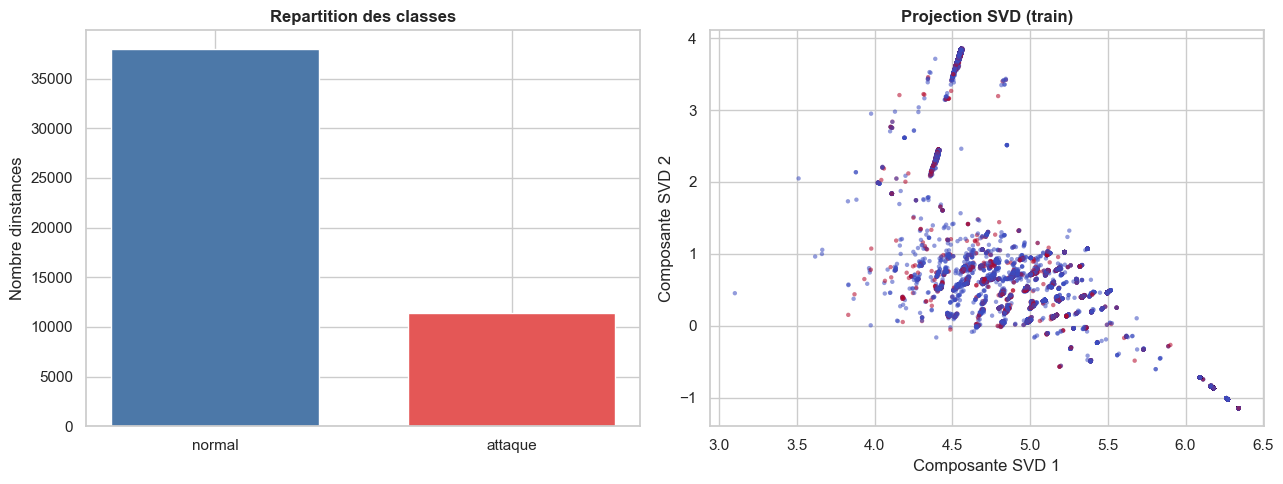

In [5]:
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import optuna

from pyclustering.cluster.cure import cure
from pyclustering.utils import timedcall

sns.set_theme(style='whitegrid')
np.random.seed(42)

# =============================================
# 1) Chargement du dataset + sous-echantillon 1%
# =============================================
cache_dir = Path.home() / 'scikit_learn_data' / 'kddcup99_10-py3'
if cache_dir.exists():
    shutil.rmtree(cache_dir, ignore_errors=True)

kdd = fetch_kddcup99(percent10=True, as_frame=True, random_state=42)
df = kdd.frame.copy() if kdd.frame is not None else pd.DataFrame(kdd.data, columns=kdd.feature_names)

# Sous-echantillon de 1% du dataset complet KDD Cup 99
df_1pct = df.sample(frac=0.10, random_state=42).reset_index(drop=True)

target_source = df_1pct['target'] if 'target' in df_1pct.columns else pd.Series(kdd.target, index=df.index).iloc[df_1pct.index]
y_raw = target_source.astype(str)
y = np.where(y_raw == 'normal.', 0, 1).astype(int)
X_raw = df_1pct.drop(columns=['target']) if 'target' in df_1pct.columns else df_1pct.copy()

categorical_cols = X_raw.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X_raw.columns.difference(categorical_cols).tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
    ],
    sparse_threshold=1.0,
    remainder='drop',
)

X = preprocessor.fit_transform(X_raw)
X = X.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp, shuffle=True
)

# Reduction de dimension pour rendre CURE plus stable et plus rapide sur KDD
n_components = min(25, X_train.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_train_cure = svd.fit_transform(X_train)
X_val_cure = svd.transform(X_val)
X_test_cure = svd.transform(X_test)

print(f'Dataset 1% KDD Cup 99: {X.shape[0]} echantillons')
print(f'Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Features apres encodage: {X.shape[1]}')
print(f'Features apres reduction SVD: {X_train_cure.shape[1]}')
print(f'Classe normale: {(y == 0).sum()} | Classe attaque: {(y == 1).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
class_counts = np.bincount(y, minlength=2)
axes[0].bar([0, 1], class_counts, color=['#4c78a8', '#e45756'], width=0.7)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['normal', 'attaque'])
axes[0].set_title('Repartition des classes', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre dinstances')

axes[1].scatter(X_train_cure[:, 0], X_train_cure[:, 1], c=y_train, cmap='coolwarm', s=10, alpha=0.55, linewidths=0)
axes[1].set_title('Projection SVD (train)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Composante SVD 1')
axes[1].set_ylabel('Composante SVD 2')

plt.tight_layout()
plt.show()

In [8]:
def apply_cure_simple(X_data, k=2, representative_size=5, compression=0.5):
    sample = X_data.tolist()
    try:
        cure_instance = cure(sample, k, representative_size, compression, ccore=True)
        ticks, _ = timedcall(cure_instance.process)
    except OSError:
        # Fallback Python si le backend C-core depasse la pile.
        cure_instance = cure(sample, k, representative_size, compression, ccore=False)
        ticks, _ = timedcall(cure_instance.process)
    clusters = cure_instance.get_clusters()
    return clusters, ticks

def clusters_to_labels(clusters, n_samples):
    labels = np.full(n_samples, fill_value=-1, dtype=int)
    for cluster_id, idxs in enumerate(clusters):
        labels[idxs] = cluster_id
    return labels

In [9]:
results = []

def make_tuning_subset(X_data, y_data, max_samples, seed):
    if len(y_data) <= max_samples:
        return X_data, y_data
    idx = np.arange(len(y_data))
    _, idx_sub = train_test_split(idx, test_size=max_samples, stratify=y_data, random_state=seed)
    return X_data[idx_sub], y_data[idx_sub]

X_train_tune, y_train_tune = make_tuning_subset(X_train, y_train, max_samples=8000, seed=42)
X_val_tune, y_val_tune = make_tuning_subset(X_val, y_val, max_samples=3000, seed=43)

print(f'Tuning subset train: {X_train_tune.shape[0]} | val: {X_val_tune.shape[0]}')

def objective(trial):
    n_components_trial = trial.suggest_int('n_components', 10, min(40, X_train_tune.shape[1] - 1))
    k = trial.suggest_int('k', 2, 6)
    representative_size = trial.suggest_categorical('representative_size', [5, 10, 20, 30])
    compression = trial.suggest_float('compression', 0.03, 0.25, log=False)

    try:
        svd_trial = TruncatedSVD(n_components=n_components_trial, random_state=42)
        X_train_trial = svd_trial.fit_transform(X_train_tune)
        X_val_trial = svd_trial.transform(X_val_tune)

        clusters_train, ticks_train = apply_cure_simple(X_train_trial, k=k, representative_size=representative_size, compression=compression)
        _ = clusters_to_labels(clusters_train, len(X_train_trial))

        clusters_val, _ = apply_cure_simple(X_val_trial, k=k, representative_size=representative_size, compression=compression)
        val_labels = clusters_to_labels(clusters_val, len(X_val_trial))

        ari = adjusted_rand_score(y_val_tune, val_labels)
        nmi = normalized_mutual_info_score(y_val_tune, val_labels)
        sil = silhouette_score(X_val_trial, val_labels) if len(np.unique(val_labels)) > 1 else np.nan
        silhouette_norm = 0.0 if np.isnan(sil) else ((sil + 1.0) / 2.0)
        score = 0.45 * ari + 0.45 * nmi + 0.10 * silhouette_norm
    except (OSError, RuntimeError, ValueError) as err:
        print(f'Essai {trial.number + 1} ignore ({type(err).__name__}): {err}')
        return -1.0

    result = {
        'trial': trial.number + 1,
        'n_components': n_components_trial,
        'k': k,
        'rep_size': representative_size,
        'compression': compression,
        'time_sec': ticks_train,
        'ari': float(ari),
        'nmi': float(nmi),
        'silhouette': float(sil),
        'score': float(score),
    }
    results.append(result)

    print(f"Essai {trial.number + 1} | n_comp={n_components_trial} k={k} rep={representative_size} comp={compression:.3f} | "
          f"ARI={ari:.4f} NMI={nmi:.4f} SIL={sil:.4f} | score={score:.4f}")
    return score

study = optuna.create_study(direction='maximize', study_name='cure_kdd_1pct')
study.optimize(objective, n_trials=20, show_progress_bar=False, catch=(OSError, RuntimeError, ValueError))

if len(results) == 0:
    raise RuntimeError('Aucun essai valide. Reduire encore max_samples ou n_components.')

best_result = max(results, key=lambda r: r['score'])
print('\nMeilleur modele (selection validation):')
print(best_result)
print('Best trial Optuna:')
print(study.best_trial.params)

[I 2026-04-17 09:49:38,491] A new study created in memory with name: cure_kdd_1pct


Tuning subset train: 8000 | val: 3000


[I 2026-04-17 09:50:01,218] Trial 0 finished with value: 0.08571714593145366 and parameters: {'n_components': 18, 'k': 6, 'representative_size': 20, 'compression': 0.10053158238812133}. Best is trial 0 with value: 0.08571714593145366.


Essai 1 | n_comp=18 k=6 rep=20 comp=0.101 | ARI=0.0068 NMI=0.0017 SIL=0.6379 | score=0.0857


[I 2026-04-17 09:50:17,338] Trial 1 finished with value: 0.08607742101645112 and parameters: {'n_components': 14, 'k': 6, 'representative_size': 5, 'compression': 0.15660643300528893}. Best is trial 1 with value: 0.08607742101645112.


...

Essai 18 | n_comp=20 k=4 rep=5 comp=0.075 | ARI=-0.0028 NMI=0.0004 SIL=0.4923 | score=0.0736


[I 2026-04-17 09:58:20,691] Trial 18 finished with value: 0.07746278435176213 and parameters: {'n_components': 11, 'k': 3, 'representative_size': 5, 'compression': 0.12703425560319043}. Best is trial 11 with value: 0.08625436259481425.


Essai 19 | n_comp=11 k=3 rep=5 comp=0.127 | ARI=-0.0050 NMI=0.0002 SIL=0.5924 | score=0.0775


[I 2026-04-17 09:58:56,176] Trial 19 finished with value: 0.07259771938009184 and parameters: {'n_components': 29, 'k': 6, 'representative_size': 30, 'compression': 0.20770773651004823}. Best is trial 11 with value: 0.08625436259481425.


Essai 20 | n_comp=29 k=6 rep=30 comp=0.208 | ARI=-0.0031 NMI=0.0013 SIL=0.4678 | score=0.0726

Meilleur modele (selection validation):
{'trial': 12, 'n_components': 16, 'k': 6, 'rep_size': 5, 'compression': 0.10928481568393046, 'time_sec': 21.167391599999974, 'ari': 0.0068404372459263466, 'nmi': 0.0016535818909686384, 'silhouette': 0.648641049861908, 'score': 0.08625436259481425}
Best trial Optuna:
{'n_components': 16, 'k': 6, 'representative_size': 5, 'compression': 0.10928481568393046}


Protocole: hyperparametres selectionnes sur validation
Evaluation finale sur TEST (une seule fois)
Hyperparametres retenus: n_components=16, k=6, rep_size=5, compression=0.109
Temps test: 18.9740s
ARI: 0.0029
NMI: 0.0003
Silhouette: 0.5494

Matrice de confusion (classes vraies x clusters predits):
[[1116 3294    1    2  289  993]
 [ 353  977    0    0   98  288]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]
 [   0    0    0    0    0    0]]


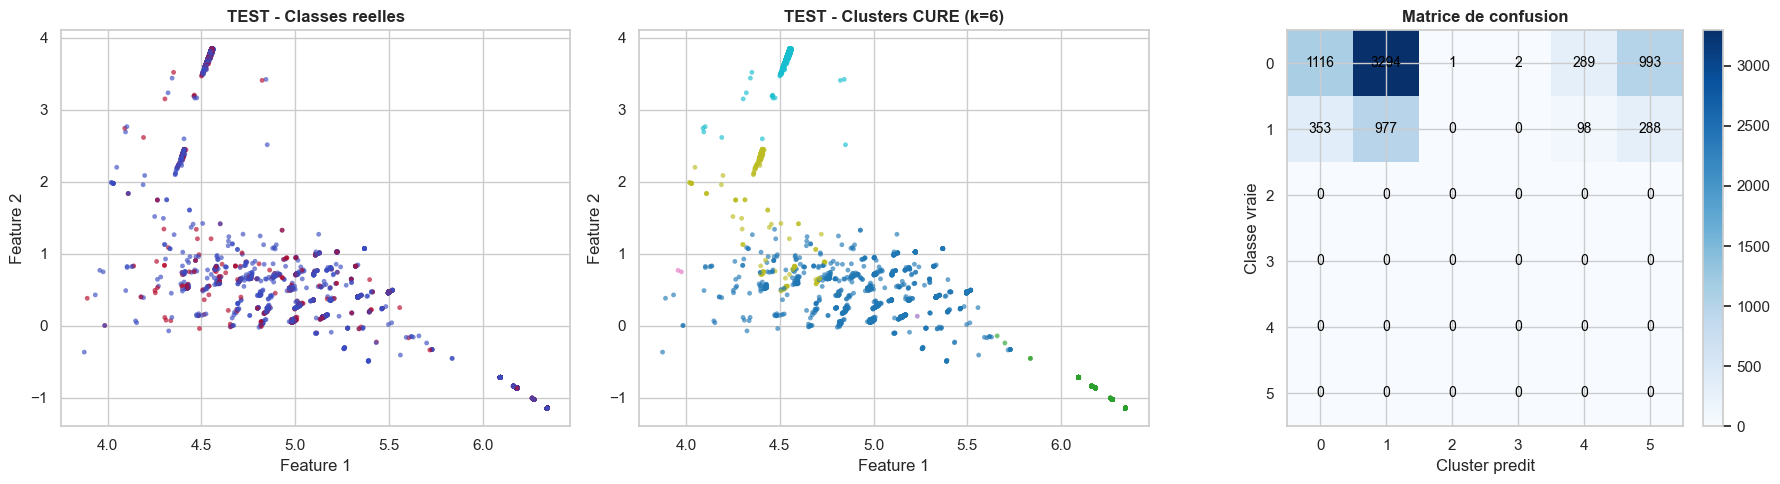

In [10]:
from sklearn.metrics import confusion_matrix

# Test directement avec les hyperparametres optimaux
n_components_test = best_result['n_components']
svd_test = TruncatedSVD(n_components=n_components_test, random_state=42)
X_train_test = svd_test.fit_transform(X_train)
X_test_cure = svd_test.transform(X_test)
clusters_test, ticks_test = apply_cure_simple(
    X_test_cure,
    k=best_result['k'],
    representative_size=best_result['rep_size'],
    compression=best_result['compression']
)
test_labels = clusters_to_labels(clusters_test, len(X_test_cure))

# Metriques de test
ari_test = adjusted_rand_score(y_test, test_labels)
nmi_test = normalized_mutual_info_score(y_test, test_labels)
sil_test = silhouette_score(X_test_cure, test_labels)
cm = confusion_matrix(y_test, test_labels)

print('Protocole: hyperparametres selectionnes sur validation')
print('Evaluation finale sur TEST (une seule fois)')
print(f"Hyperparametres retenus: n_components={best_result['n_components']}, k={best_result['k']}, rep_size={best_result['rep_size']}, compression={best_result['compression']:.3f}")
print(f"Temps test: {ticks_test:.4f}s")
print(f"ARI: {ari_test:.4f}")
print(f"NMI: {nmi_test:.4f}")
print(f"Silhouette: {sil_test:.4f}")
print('\nMatrice de confusion (classes vraies x clusters predits):')
print(cm)

# Visualisations
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

feature_test_preview = X_test_cure[:, :2] if X_test_cure.shape[1] >= 2 else X_test_cure
axes[0].scatter(feature_test_preview[:, 0], feature_test_preview[:, 1], c=y_test, cmap='coolwarm', s=12, alpha=0.65, linewidths=0)
axes[0].set_title('TEST - Classes reelles', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(feature_test_preview[:, 0], feature_test_preview[:, 1], c=test_labels, cmap='tab10', s=12, alpha=0.65, linewidths=0)
axes[1].set_title(f'TEST - Clusters CURE (k={best_result["k"]})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Matrice de confusion', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster predit')
axes[2].set_ylabel('Classe vraie')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=10)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()